# Customer Segmentation using RFM Analysis
Proyek ini bertujuan untuk mengelompokkan pelanggan berdasarkan perilaku belanja mereka (Recency, Frequency, Monetary) menggunakan dataset Online Retail. Data ditarik dari database MySQL dan dianalisis menggunakan Python.

In [2]:
# Import library analitik visual
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# MENGIMPOR fungsi dari file database_connection.py buatanmu sendiri!
from database_connection import fetch_rfm_data

# Menarik data dari database
df_rfm = fetch_rfm_data()

# Menampilkan data
df_rfm.head()

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,18,1,1757.55
4,12350,310,1,334.40


## RFM Scoring
Data akan dinilai dengan skala 1-5 menggunakan fungsi Quantile. 
* Catatan: Untuk **Recency**, angka hari yang lebih kecil (lebih baru) akan mendapatkan skor yang lebih tinggi (5).

In [3]:
# Scoring menggunakan pd.qcut (membagi data menjadi 5 kelompok yang sama besar)
df_rfm['R_Score'] = pd.qcut(df_rfm['Recency'], 5, labels=[5, 4, 3, 2, 1])
df_rfm['F_Score'] = pd.qcut(df_rfm['Frequency'].rank(method='first'), 5, labels=[1, 2, 3, 4, 5])
df_rfm['M_Score'] = pd.qcut(df_rfm['Monetary'], 5, labels=[1, 2, 3, 4, 5])

# Menggabungkan skor menjadi string (misal: "555")
df_rfm['RFM_Cell'] = df_rfm['R_Score'].astype(str) + df_rfm['F_Score'].astype(str) + df_rfm['M_Score'].astype(str)

df_rfm.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Cell
0,12346,325,1,77183.60,1,1,5,115
1,12347,2,7,4310.00,5,5,5,555
2,12348,75,4,1797.24,2,4,4,244
3,12349,18,1,1757.55,4,1,4,414
4,12350,310,1,334.40,1,1,2,112


In [4]:
# Fungsi untuk menentukan segmen pelanggan
def rfm_segmentation(df):
    r = int(df['R_Score'])
    f = int(df['F_Score'])
    
    if r >= 4 and f >= 4:
        return '🏆 Champions / Loyal'
    elif r >= 3 and f >= 3:
        return '🌟 Potential Loyalist'
    elif r <= 2 and f >= 3:
        return '⚠️ At-Risk Customers'
    elif r <= 2 and f <= 2:
        return 'ZZZ Hibernating / Churned'
    else:
        return 'Others'

# Menerapkan fungsi ke DataFrame
df_rfm['Segment'] = df_rfm.apply(rfm_segmentation, axis=1)

# Melihat jumlah pelanggan di tiap segmen
segment_counts = df_rfm['Segment'].value_counts()
print(segment_counts)

Segment
🏆 Champions / Loyal          1128
ZZZ Hibernating / Churned    1071
🌟 Potential Loyalist          819
Others                        664
⚠️ At-Risk Customers          656
Name: count, dtype: int64


C:\Users\ASUS\AppData\Local\Temp\ipykernel_39740\2175951373.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_rfm, y='Segment', order=df_rfm['Segment'].value_counts().index, palette='viridis')
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127942 (\N{TROPHY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\ASUS\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 127775 (\N{GLOWING STAR}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


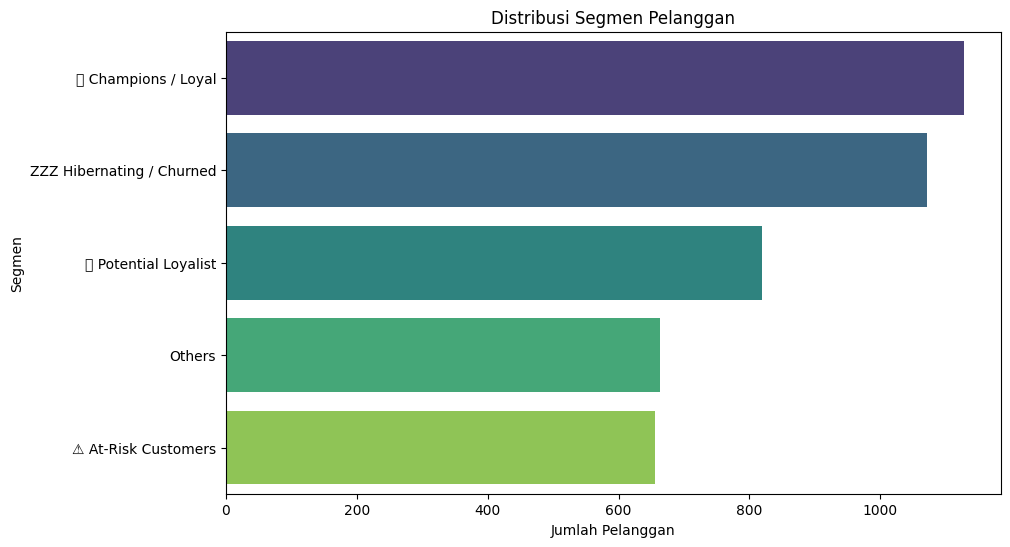

In [5]:
# Membuat visualisasi bar chart sederhana
plt.figure(figsize=(10, 6))
sns.countplot(data=df_rfm, y='Segment', order=df_rfm['Segment'].value_counts().index, palette='viridis')
plt.title('Distribusi Segmen Pelanggan')
plt.xlabel('Jumlah Pelanggan')
plt.ylabel('Segmen')
plt.show()

In [6]:
# Mengekspor hasil akhir ke CSV untuk dibuatkan Dashboard interaktif di Google Sheets
df_rfm.to_csv('rfm_segmented_final.csv', index=False)
print("Data berhasil diekspor menjadi rfm_segmented_final.csv!")

Data berhasil diekspor menjadi rfm_segmented_final.csv!
